## Network Analysis

In [3]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import networkx as nx
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import community as community_louvain

plt.style.use('seaborn-v0_8-colorblind')
CLEAN = 'clean'

In [5]:
# color scheme
RELIABILITY_LOW = '#2E7D32'    # reliable = green
RELIABILITY_HIGH = '#D32F2F'   # questionable = red
RELIABILITY_MIXED = '#C9A029'  # midpoint blend

RELIABILITY_COLORS = {
    'Reliable': RELIABILITY_LOW,
    'Mixed': RELIABILITY_MIXED,
    'Questionable': RELIABILITY_HIGH,
}

LEANING_MARKERS = {
    'Left': '^',           # triangle up
    'Left-Center': 'o',    # circle
    'Neutral': 's',        # square
    'Right-Center': 'D',   # diamond
    'Right': '*',          # star
}

RELIABILITY_SCORES = {'Reliable': 0, 'Mixed': 0.5, 'Questionable': 1}

In [7]:
## network ##


def build_similarity_network(edge_path, label):
    # load edge list with MBFC labels
    raw = pd.read_csv(edge_path, dtype=str)
    raw['weight'] = pd.to_numeric(raw['weight'], errors='coerce').fillna(0)

    # build unified node label table from source and target roles
    source_labels = raw[raw['source_bias'].notna() | raw['source_factuality'].notna()][
        ['source', 'source_bias', 'source_factuality']
    ].rename(columns={'source': 'account', 'source_bias': 'bias', 'source_factuality': 'factuality'})

    target_labels = raw[raw['target_bias'].notna() | raw['target_factuality'].notna()][
        ['target', 'target_bias', 'target_factuality']
    ].rename(columns={'target': 'account', 'target_bias': 'bias', 'target_factuality': 'factuality'})

    node_labels = pd.concat([source_labels, target_labels]).drop_duplicates(subset='account')

    # map to display labels
    fact_map = {'high': 'Reliable', 'mixed': 'Mixed', 'low': 'Questionable'}
    bias_map = {'left': 'Left', 'left-center': 'Left-Center', 'neutral': 'Neutral',
                'right-center': 'Right-Center', 'right': 'Right'}

    node_labels['reliability'] = node_labels['factuality'].map(fact_map).fillna('No label')
    node_labels['leaning'] = node_labels['bias'].map(bias_map).fillna('No label')

    # edge list without self-loops, aggregated
    edges = raw[['source', 'target', 'weight']].copy()
    edges = edges[edges['source'] != edges['target']]
    edges = edges.groupby(['source', 'target'])['weight'].sum().reset_index()

    # node set = MBFC-labeled accounts that have been reposted at least once
    valid_targets = set(edges['target'])
    labeled_accounts = set(node_labels[
        (node_labels['reliability'] != 'No label') | (node_labels['leaning'] != 'No label')
    ]['account'])
    node_set = labeled_accounts & valid_targets

    print(f"{label}: {len(labeled_accounts)} MBFC-labeled, {len(node_set)} reposted at least once")

    # build directed graph and interaction matrix
    edge_reduced = edges[edges['target'].isin(node_set)]
    G = nx.from_pandas_edgelist(edge_reduced, 'source', 'target', 'weight', create_using=nx.DiGraph())

    # interaction matrix: rows = audience (reposters not in node_set), cols = node_set
    node_list = sorted(node_set)
    all_nodes = sorted(set(G.nodes()))
    audience = sorted(set(all_nodes) - node_set)

    node_to_idx_col = {n: i for i, n in enumerate(node_list)}
    node_to_idx_row = {n: i for i, n in enumerate(audience)}

    rows, cols, data = [], [], []
    for u, v, d in G.edges(data=True):
        if u in node_to_idx_row and v in node_to_idx_col:
            rows.append(node_to_idx_row[u])
            cols.append(node_to_idx_col[v])
            data.append(d['weight'])

    interaction = csr_matrix((data, (rows, cols)), shape=(len(audience), len(node_list)))

    # cosine similarity between labeled accounts based on shared audience
    cos_sim = cosine_similarity(interaction.T)
    np.fill_diagonal(cos_sim, 0)

    med = np.median(cos_sim[np.triu_indices_from(cos_sim, k=1)])
    print(f"{label}: median cosine similarity = {med:.4f}")

    # build similarity graph
    G_sim = nx.Graph()
    for i, ni in enumerate(node_list):
        attrs = node_labels[node_labels['account'] == ni].iloc[0] if ni in node_labels['account'].values else {}
        G_sim.add_node(ni,
            reliability=attrs.get('reliability', 'No label') if isinstance(attrs, dict) == False else attrs['reliability'],
            leaning=attrs.get('leaning', 'No label') if isinstance(attrs, dict) == False else attrs['leaning'],
        )

    # add edges above median similarity
    for i in range(len(node_list)):
        for j in range(i+1, len(node_list)):
            if cos_sim[i, j] > med:
                G_sim.add_edge(node_list[i], node_list[j], weight=cos_sim[i, j])

    # remove isolated nodes
    isolates = list(nx.isolates(G_sim))
    G_sim.remove_nodes_from(isolates)

    print(f"{label}: similarity network = {G_sim.number_of_nodes()} nodes, {G_sim.number_of_edges()} edges")

    # Louvain community detection (resolution=1.2 matching R script)
    partition = community_louvain.best_partition(G_sim, resolution=1.2, random_state=42)
    mod = community_louvain.modularity(partition, G_sim)
    n_clusters = len(set(partition.values()))
    print(f"{label}: Louvain modularity = {mod:.4f}, {n_clusters} clusters")

    nx.set_node_attributes(G_sim, partition, 'community')

    return G_sim, cos_sim, node_list, partition, node_labels

In [9]:
## both networks 


# build both networks
G_bsky, cos_bsky, nodes_bsky, part_bsky, labels_bsky = build_similarity_network(
    f'{CLEAN}/bsky_repost_edgelist_updated.csv', 'Bluesky'
)
G_truth, cos_truth, nodes_truth, part_truth, labels_truth = build_similarity_network(
    f'{CLEAN}/truth_repost_edgelist_updated.csv', 'Truth Social'
)

Bluesky: 1458 MBFC-labeled, 1197 reposted at least once
Bluesky: median cosine similarity = 0.0000
Bluesky: similarity network = 988 nodes, 31239 edges
Bluesky: Louvain modularity = 0.4644, 17 clusters
Truth Social: 430 MBFC-labeled, 167 reposted at least once
Truth Social: median cosine similarity = 0.0000
Truth Social: similarity network = 92 nodes, 370 edges
Truth Social: Louvain modularity = 0.5339, 13 clusters


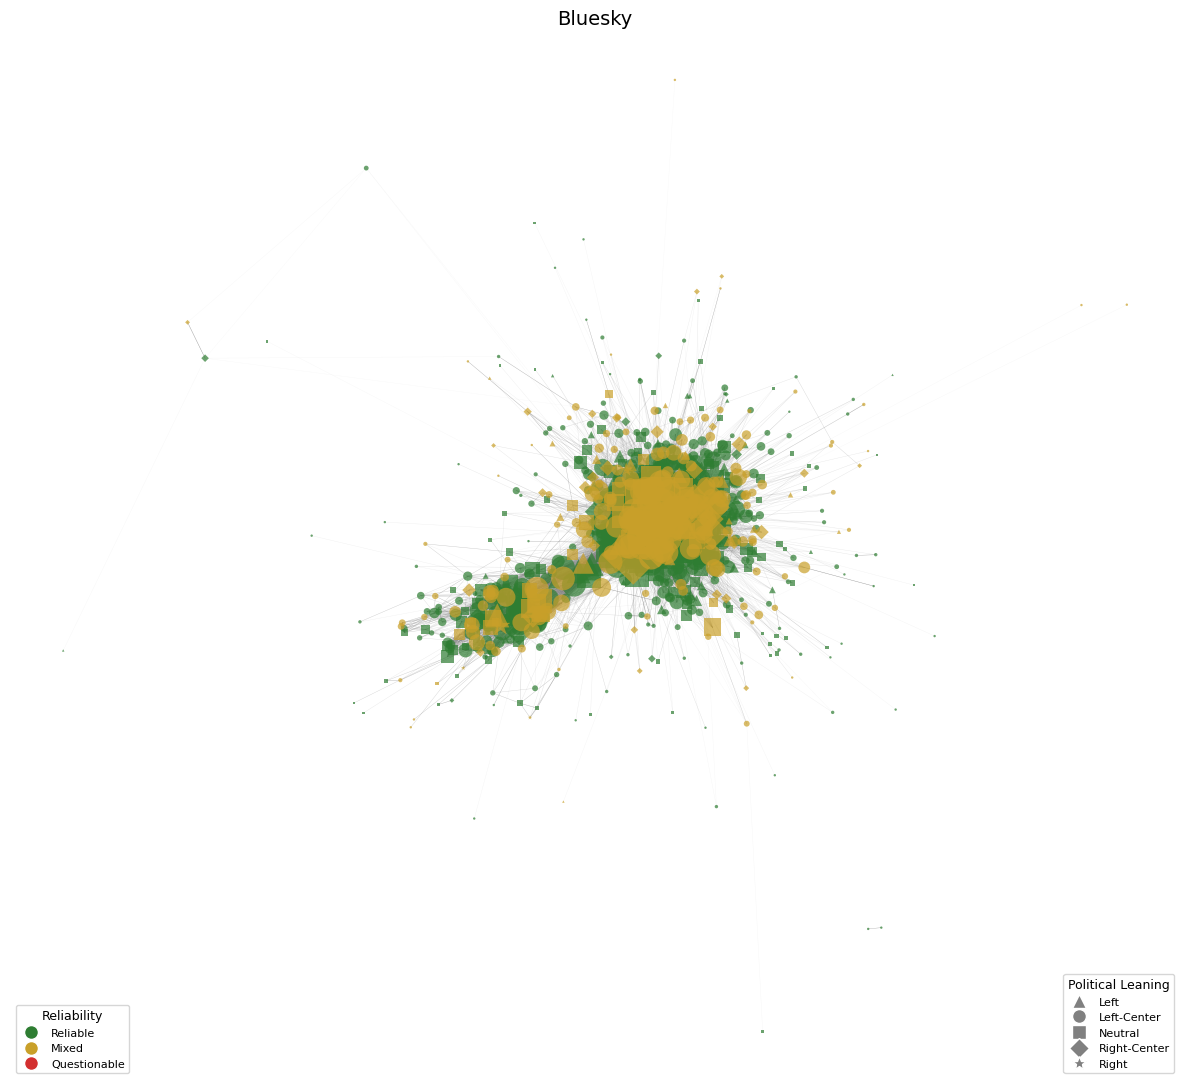

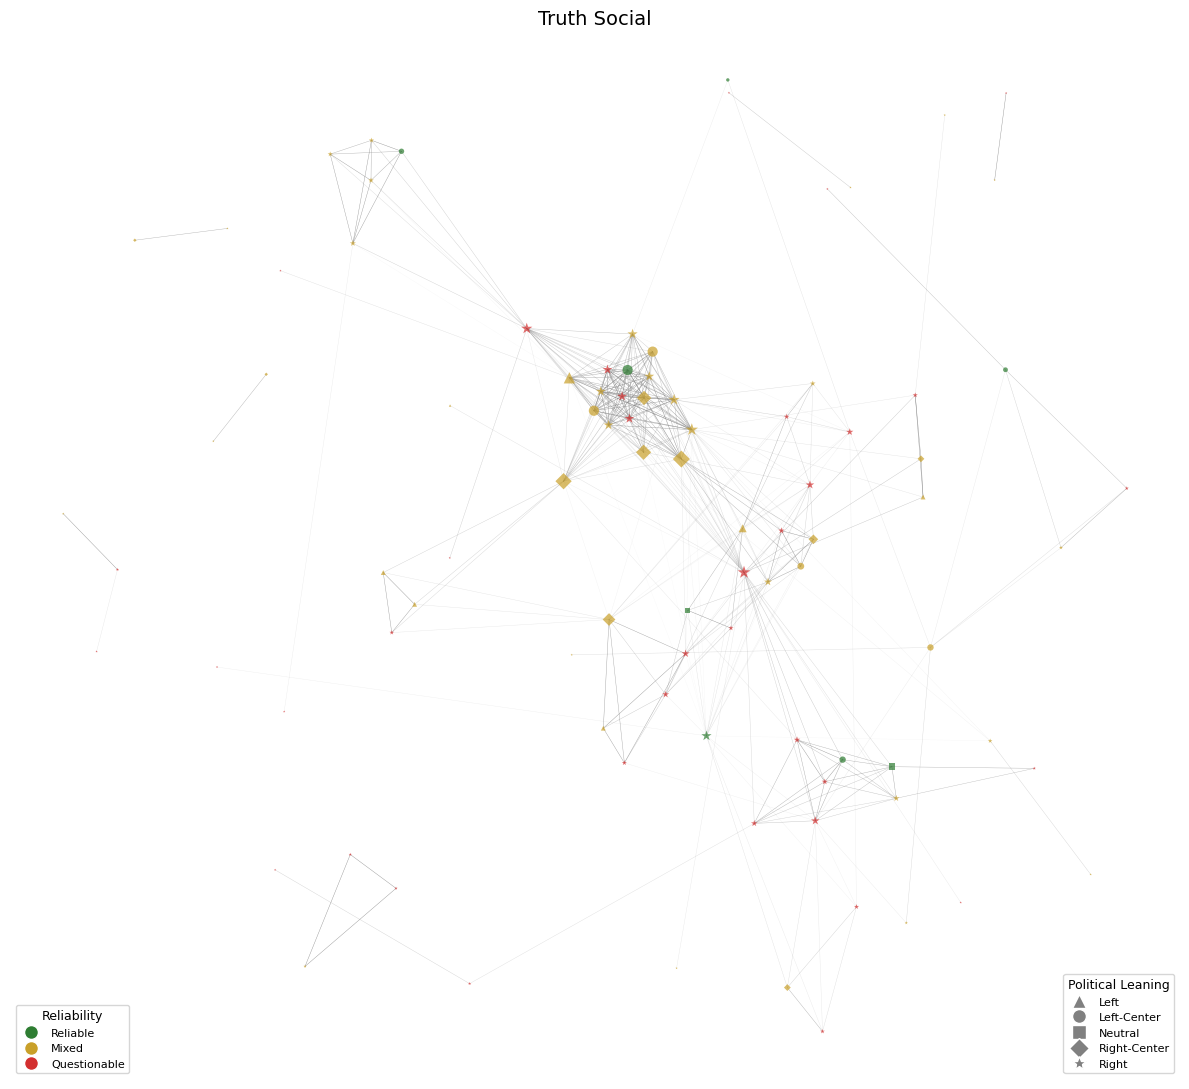

In [10]:
## plot networks 

def plot_network(G, title, save_path):
    pos = nx.spring_layout(G, k=0.3, seed=42, iterations=50)

    fig, ax = plt.subplots(figsize=(12, 11))

    # draw edges with alpha based on weight
    weights = [G[u][v]['weight'] for u, v in G.edges()]
    w_min, w_max = min(weights), max(weights)
    for (u, v), w in zip(G.edges(), weights):
        alpha = 0.05 + 0.8 * (w - w_min) / (w_max - w_min + 1e-9)
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='gray', alpha=alpha, linewidth=0.3, zorder=0)

    # draw nodes grouped by reliability + leaning
    for rel in ['Reliable', 'Mixed', 'Questionable']:
        for lean in ['Left', 'Left-Center', 'Neutral', 'Right-Center', 'Right']:
            subset = [n for n in G.nodes() if
                      G.nodes[n].get('reliability') == rel and
                      G.nodes[n].get('leaning') == lean]
            if not subset:
                continue
            x = [pos[n][0] for n in subset]
            y = [pos[n][1] for n in subset]
            sizes = [min(G.degree(n) * 3, 300) for n in subset]
            ax.scatter(x, y, c=RELIABILITY_COLORS[rel], marker=LEANING_MARKERS[lean],
                      s=sizes, alpha=0.7, edgecolors='none', zorder=1)

    # legend
    rel_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l)
                   for l, c in RELIABILITY_COLORS.items()]
    lean_handles = [Line2D([0], [0], marker=m, color='w', markerfacecolor='gray', markersize=10, label=l)
                    for l, m in LEANING_MARKERS.items()]

    leg1 = ax.legend(handles=rel_handles, title='Reliability', loc='lower left', fontsize=8, title_fontsize=9)
    ax.add_artist(leg1)
    ax.legend(handles=lean_handles, title='Political Leaning', loc='lower right', fontsize=8, title_fontsize=9)

    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_network(G_bsky, 'Bluesky', f'{CLEAN}/fig_network_bsky_louvain.png')
plot_network(G_truth, 'Truth Social', f'{CLEAN}/fig_network_truth_louvain.png')

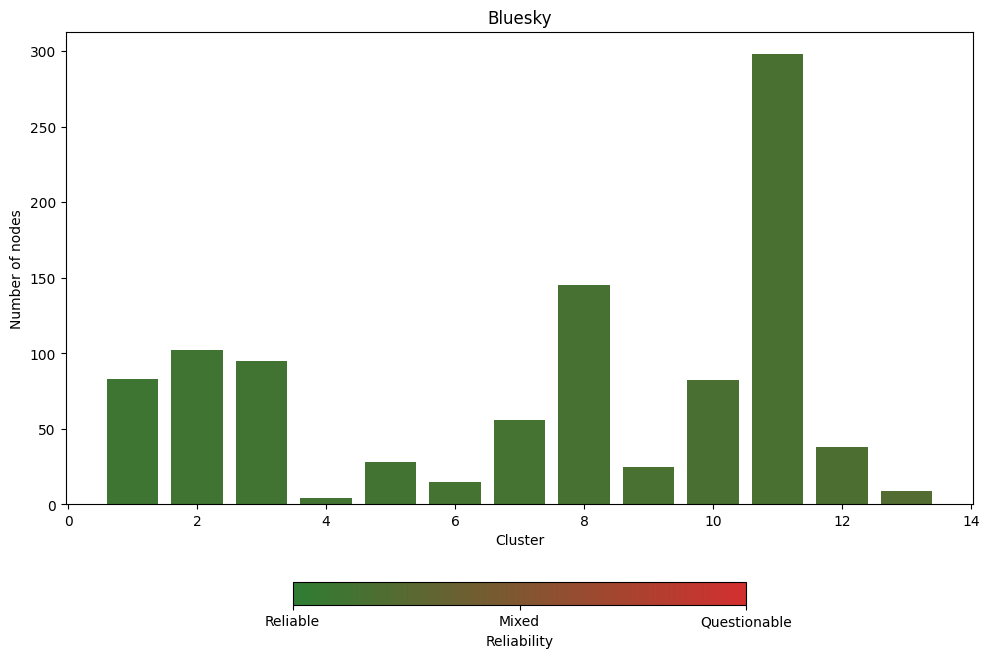

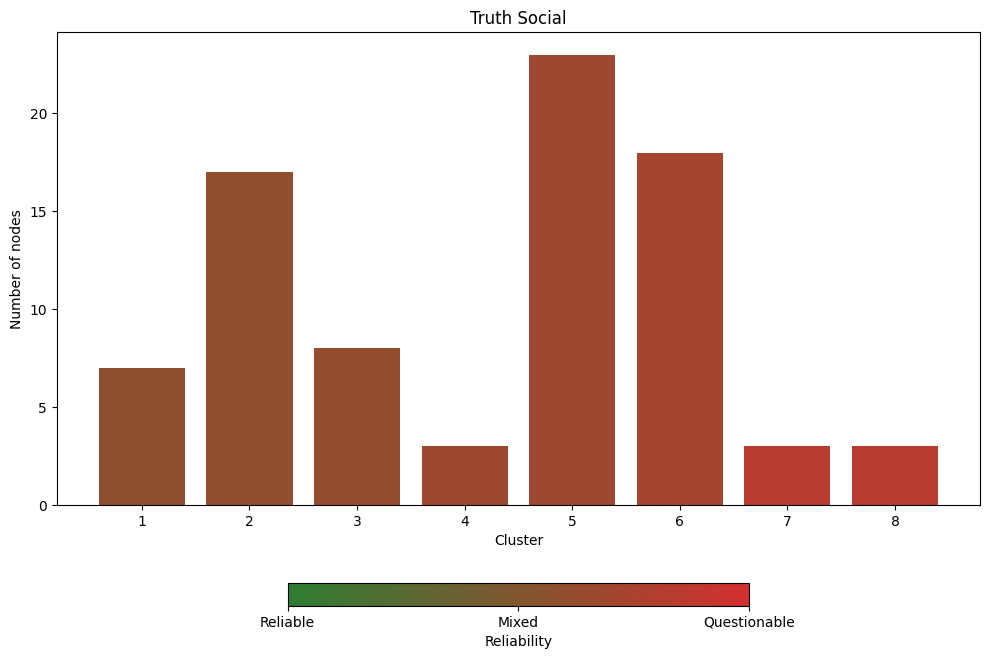

In [11]:
## plot communities 


def plot_communities(G, partition, title, save_path):
    # community composition by reliability
    comm_data = []
    for node in G.nodes():
        comm_data.append({
            'community': partition[node],
            'reliability': G.nodes[node].get('reliability', 'No label'),
        })
    comm_df = pd.DataFrame(comm_data)

    # mean reliability score per community
    comm_df['score'] = comm_df['reliability'].map(RELIABILITY_SCORES).fillna(0.5)
    comm_summary = comm_df.groupby('community').agg(
        count=('score', 'size'),
        mean_score=('score', 'mean'),
    ).reset_index()

    # drop tiny clusters (matching R script)
    comm_summary = comm_summary[comm_summary['count'] > 2]
    comm_summary = comm_summary.sort_values(['mean_score', 'count']).reset_index(drop=True)
    comm_summary['label'] = range(1, len(comm_summary) + 1)

    # colormap matching R script gradient
    cmap = mcolors.LinearSegmentedColormap.from_list('rel', [RELIABILITY_LOW, RELIABILITY_HIGH])
    norm = mcolors.Normalize(vmin=0, vmax=1)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.bar(comm_summary['label'], comm_summary['count'],
                  color=[cmap(norm(s)) for s in comm_summary['mean_score']])

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.12, shrink=0.5)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Reliable', 'Mixed', 'Questionable'])
    cbar.set_label('Reliability')

    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of nodes')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_communities(G_bsky, part_bsky, 'Bluesky', f'{CLEAN}/fig_communities_bsky.png')
plot_communities(G_truth, part_truth, 'Truth Social', f'{CLEAN}/fig_communities_truth.png')

In [12]:
## pro AI / anti AI labels bsky


# add AI stance to network nodes based on keyword posting patterns
bsky_posts = pd.read_csv(f'{CLEAN}/bsky_aligned.csv', usecols=['author_did', 'search_keyword'])

PRO_TERMS = {'pro-AI', 'AI powered', 'AI breakthrough', 'AI agents', 'GenAI'}
ANTI_TERMS = {'anti-AI', 'AI slop', 'AI hallucination', 'AI water', 'AI energy'}

author_stance = bsky_posts.groupby('author_did').agg(
    pro=('search_keyword', lambda x: x.isin(PRO_TERMS).sum()),
    anti=('search_keyword', lambda x: x.isin(ANTI_TERMS).sum()),
).reset_index()
author_stance['stance'] = 'neutral'
author_stance.loc[author_stance['pro'] > author_stance['anti'], 'stance'] = 'pro-AI'
author_stance.loc[author_stance['anti'] > author_stance['pro'], 'stance'] = 'anti-AI'

# cross-reference stance with Louvain communities
stance_map = dict(zip(author_stance['author_did'], author_stance['stance']))
comm_stance = []
for node in G_bsky.nodes():
    comm_stance.append({
        'community': part_bsky[node],
        'stance': stance_map.get(node, 'unknown'),
        'reliability': G_bsky.nodes[node].get('reliability', 'No label'),
    })
comm_stance_df = pd.DataFrame(comm_stance)

print("Bluesky: Louvain community x AI stance")
print(pd.crosstab(comm_stance_df['community'], comm_stance_df['stance'], margins=True))

Bluesky: Louvain community x AI stance
stance     anti-AI  neutral  pro-AI  unknown  All
community                                        
0                2       17       8       68   95
1               36       63      35      164  298
2                2        4       4       15   25
3                1        1       0       13   15
4                8       20      13       42   83
5               11       18       5       68  102
6                3        5       4      133  145
7                0        0       0        2    2
8                0        0       1        1    2
9                6       18      14       44   82
10               1        2       1       52   56
11               0        3       0        6    9
12               1        0       1        0    2
13               3        4       3       28   38
14               2        8       3       15   28
15               0        0       0        2    2
16               0        0       0        4    4
All        

In [13]:
## pro AI anti AI Truth


# same for Truth Social
truth_posts = pd.read_csv(f'{CLEAN}/truth_aligned.csv', usecols=['author_id', 'hashtag'], dtype={'author_id': str})

PRO_TERMS_T = {'proAI', 'AIpowered', 'AIbreakthrough', 'AIagents', 'GenAI'}
ANTI_TERMS_T = {'antiAI', 'AIslop', 'AIhallucination', 'AIwater', 'AIenergy'}

author_stance_t = truth_posts.groupby('author_id').agg(
    pro=('hashtag', lambda x: x.isin(PRO_TERMS_T).sum()),
    anti=('hashtag', lambda x: x.isin(ANTI_TERMS_T).sum()),
).reset_index()
author_stance_t['stance'] = 'neutral'
author_stance_t.loc[author_stance_t['pro'] > author_stance_t['anti'], 'stance'] = 'pro-AI'
author_stance_t.loc[author_stance_t['anti'] > author_stance_t['pro'], 'stance'] = 'anti-AI'

stance_map_t = dict(zip(author_stance_t['author_id'], author_stance_t['stance']))
comm_stance_t = []
for node in G_truth.nodes():
    comm_stance_t.append({
        'community': part_truth[node],
        'stance': stance_map_t.get(node, 'unknown'),
        'reliability': G_truth.nodes[node].get('reliability', 'No label'),
    })
comm_stance_t_df = pd.DataFrame(comm_stance_t)

print("Truth Social: Louvain community x AI stance")
print(pd.crosstab(comm_stance_t_df['community'], comm_stance_t_df['stance'], margins=True))

Truth Social: Louvain community x AI stance
stance     neutral  unknown  All
community                       
0               16        2   18
1                8        0    8
2                0        2    2
3                2        0    2
4                1        2    3
5                2        0    2
6                3        0    3
7                1        1    2
8               16        1   17
9                6        1    7
10               3        0    3
11               2        0    2
12              22        1   23
All             82       10   92
